In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
plt.style.use('ggplot')

df=pd.read_csv('/content/ecommerce_customer_data_custom_ratios.csv')
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [3]:
df.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47596
Customer Name,0


In [4]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_9574/173857299.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


In [6]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [8]:
print(df.shape)

(250000, 13)


In [13]:
df["Total Purchase Amount"] = df["Quantity"] * df["Product Price"]

In [15]:
df.drop(columns=["Customer Age"], inplace=True)

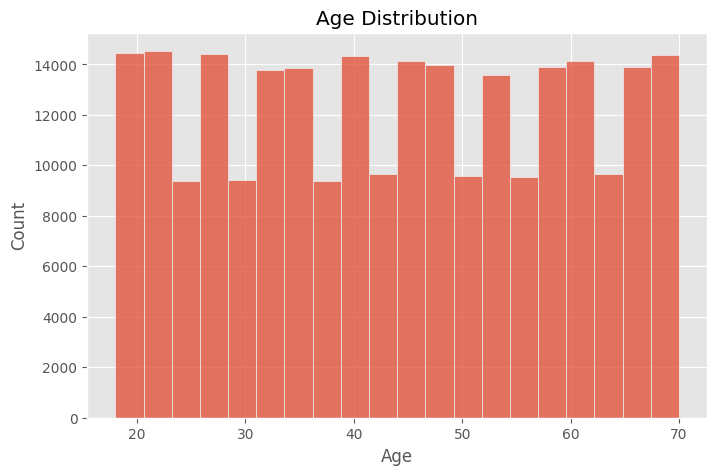

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

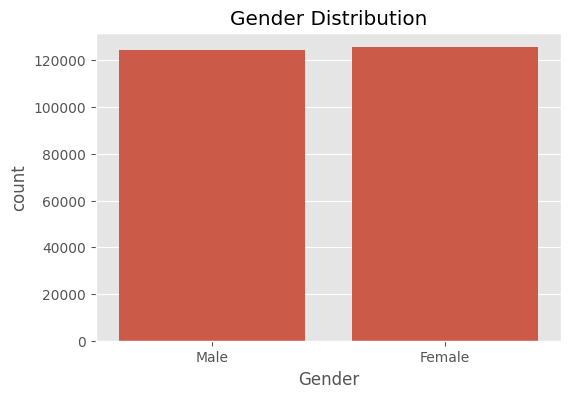

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Gender")

plt.title("Gender Distribution")

plt.show()

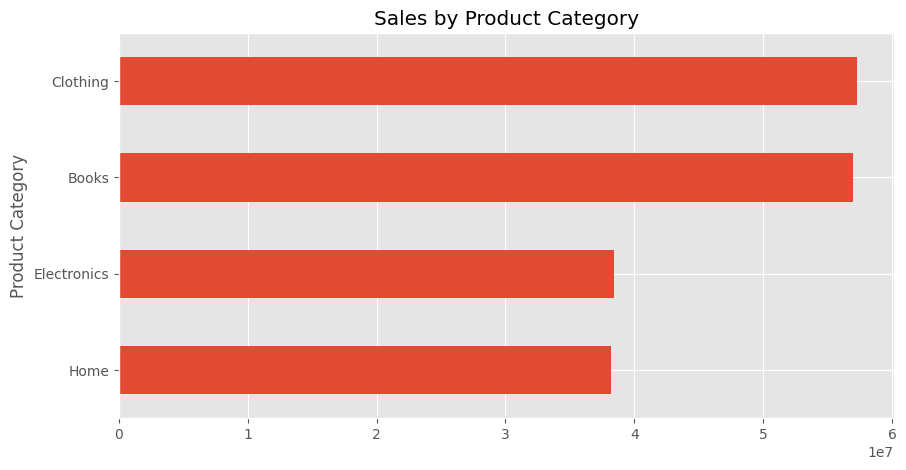

In [18]:
plt.figure(figsize=(10,5))

category=df.groupby("Product Category")["Total Purchase Amount"].sum()

category.sort_values().plot(kind="barh")

plt.title("Sales by Product Category")

plt.show()

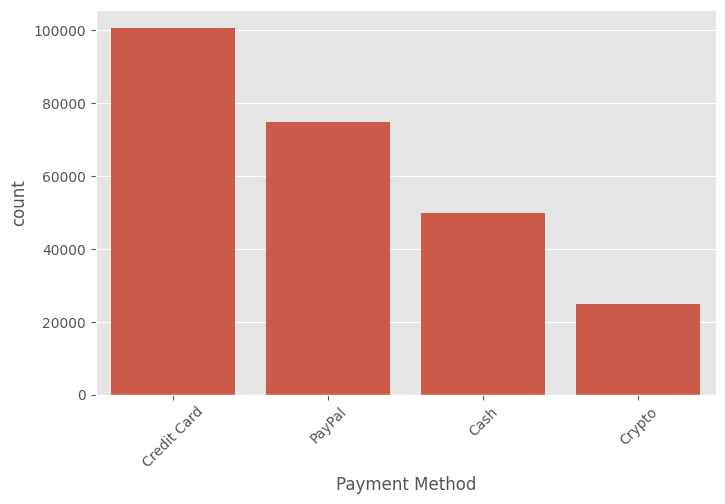

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Payment Method")

plt.xticks(rotation=45)

plt.show()

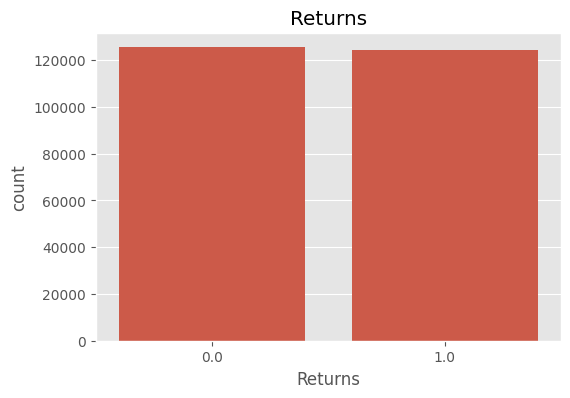

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Returns")

plt.title("Returns")

plt.show()

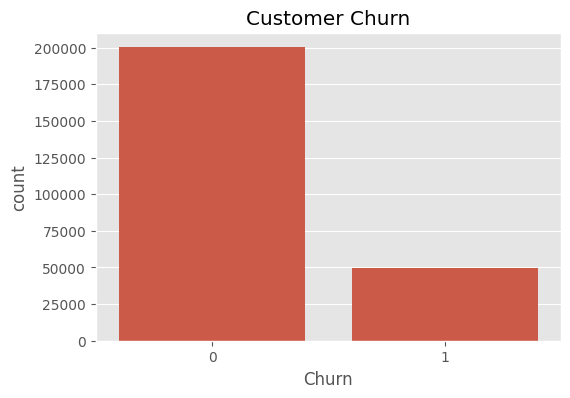

In [22]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn")

plt.show()

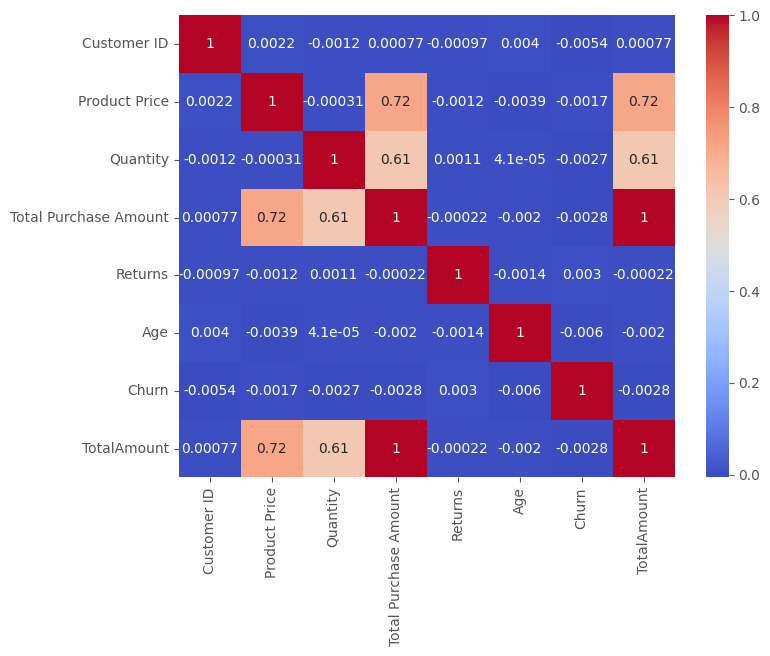

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(

df.select_dtypes(include=np.number).corr(),

annot=True,

cmap="coolwarm"

)

plt.show()

In [28]:
churn=(df["Churn"].value_counts(normalize=True)*100)

print(churn)

Churn
0    80.0504
1    19.9496
Name: proportion, dtype: float64


In [30]:
print("1. High-value customers contribute the highest revenue.")
print("2. Some customers purchase frequently but spend less.")
print("3. Customers with high recency are at risk of churn.")
print("4. Product category performance differs significantly.")
print("5. Payment methods influence purchasing behavior.")

1. High-value customers contribute the highest revenue.
2. Some customers purchase frequently but spend less.
3. Customers with high recency are at risk of churn.
4. Product category performance differs significantly.
5. Payment methods influence purchasing behavior.


In [31]:
recommendations = [

"Reward loyal customers through loyalty programs and exclusive discounts.",

"Launch personalized win-back campaigns for customers with high recency.",

"Promote high-performing product categories using targeted marketing.",

"Reduce returns by improving product quality and descriptions.",

"Use customer segments for personalized recommendations instead of mass marketing."

]

for i, rec in enumerate(recommendations, start=1):
    print(f"{i}. {rec}")

1. Reward loyal customers through loyalty programs and exclusive discounts.
2. Launch personalized win-back campaigns for customers with high recency.
3. Promote high-performing product categories using targeted marketing.
4. Reduce returns by improving product quality and descriptions.
5. Use customer segments for personalized recommendations instead of mass marketing.
